In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import datetime
import traceback
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.sparse import csr_matrix
import re

# Input file path (make sure using most recent aligned anndatas)
GE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/072025/ge_adata_matched_2025-07-31.h5ad"
SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/072025/splice_adata_matched_2025-07-31.h5ad"

# Read the input file
ge_adata = ad.read_h5ad(GE_INPUT)
splice_adata = ad.read_h5ad(SPLICE_INPUT)

# Check the number of cells and genes
print(f"Number of cells: {ge_adata.n_obs}")
print(f"Number of genes: {ge_adata.n_vars}")

Number of cells: 88515
Number of genes: 30340


In [2]:
print(splice_adata.shape)
print(ge_adata.shape)

(88515, 160252)
(88515, 30340)


### Types of QC to do before saving final splicing and GE anndatas....
- Gene expression based QC
- Splicing based QC, ensure reasonable number of junctions detected in cells... 
- Calculate nuclear vs cytoplasmic score...

In [3]:
# Clean up GE gene info...
gene_info_df = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/processed_data/gene_info_df_2025-06-22.csv")
gene_info_df["gene_symbol"] = gene_info_df["gene_name"]
ge_adata.var["gene_symbol"] = ge_adata.var.index.values
ge_adata.var_names = ge_adata.var["gene_symbol"]

# reset the index
ge_adata.var = ge_adata.var.reset_index(drop=True)
ge_adata.var = ge_adata.var.merge(gene_info_df, on="gene_symbol", how="left")
splice_adata.var["clean_gene_id"] = splice_adata.var["gene_id"].str.split(".").str[0]
splice_adata.var.drop(columns=["gene_name"], inplace=True)
ge_adata.var["clean_gene_id"] = ge_adata.var["gene_id"].str.split(".").str[0]

print("Clean up cell ids...")
# Confirm that the cell ids are the same
splice_adata.obs_names = splice_adata.obs["cell_id_clean"]
ge_adata.obs_names = ge_adata.obs["cell_id_clean"]
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values)

Clean up cell ids...


In [4]:
# how many genes in common between splicing and gene expression to start with? 
gene_info = ge_adata.var[["clean_gene_id", "gene_name", "mean_transcript_length", "mean_intron_length", "num_transcripts", "transcript_biotypes"]]
# remove index column
gene_info = gene_info.reset_index(drop=True)

### Quality-control pipeline  (overview)

1. **Flag rRNA genes**  
   * Parse the comma-separated `transcript_biotypes` column.  
   * Mark any entry that contains `rRNA` or `rRNA_pseudogene` → `is_rRNA = True`.

2. **Per-cell QC metrics** (`scanpy.pp.calculate_qc_metrics`)  
   * Input layer: raw counts  
   * Extra QC var: `is_rRNA` → adds `total_counts_is_rRNA` and `pct_counts_is_rRNA`.

3. **Batch-aware outlier detection**  
   For each `batch` separately:  
   * Compute the **median** and **MAD** (median-absolute-deviation) of  
     * library size (`total_counts`)  
     * number of detected genes (`n_genes_by_counts`) using raw counts.
   * Convert both features to robust z-scores  
     \[
       z = \frac{x-\text{median}}{\text{MAD}\times1.4826}
     \]
     (1.4826 rescales MAD to σ for a normal distribution).

4. **Cell filtering rules**  
   * │z│ > 3 for *either* library size *or* genes detected → drop  
   * `pct_counts_is_rRNA` ≥ 10 % → drop  
   * missing `broad_cell_type` annotation → drop  

5. **Result**  
   After filtering **80,904** cells remain (from initial set of 88,518).

6. **Feature selection for integration**  
   From the `predicted_log_norm_tms` layer, keep the **10 000** most highly variable genes for all downstream analyses.


In [5]:
print("=== FILTERING CELL TYPES WITH <50 CELLS ===")
# Count cells per broad_cell_type
cell_type_counts = ge_adata.obs['broad_cell_type'].value_counts()
print(f"Cell type counts before filtering:")
print(cell_type_counts.sort_values(ascending=False))

# Keep only cell types with at least 50 cells
valid_cell_types = cell_type_counts[cell_type_counts >= 50].index
print(f"\nCell types with ≥50 cells: {len(valid_cell_types)}")
print(f"Cell types being removed: {len(cell_type_counts) - len(valid_cell_types)}")

# Filter both datasets
cells_before = ge_adata.n_obs
cell_mask = ge_adata.obs['broad_cell_type'].isin(valid_cell_types)
ge_adata = ge_adata[cell_mask].copy()
splice_adata = splice_adata[cell_mask].copy()

print(f"Filtered from {cells_before} to {ge_adata.n_obs} cells")
print(f"Final cell type counts:")
print(ge_adata.obs['broad_cell_type'].value_counts().sort_values(ascending=False))

# Verify alignment
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
print("✓ Datasets remain aligned after cell type filtering")
print(splice_adata.shape), print(ge_adata.shape)

=== FILTERING CELL TYPES WITH <50 CELLS ===
Cell type counts before filtering:
broad_cell_type
Excitatory_Neuron            31183
Inhibitory_Neuron            11113
CNS_Glia                      3898
CD4_T_cell                    3188
General_Fibroblast            2915
Granulocyte                   2621
Monocyte                      2533
B_cell                        2480
Macrophage                    2426
CD8_T_cell                    2391
GI_Epithelial                 2249
Specialized_Endothelial       2195
Other                         1877
NK_ILC                        1792
Mesenchymal_Stem              1494
Plasma_cell                   1448
Other_T_cell                  1059
Alveolar_cell                  866
Capillary_Endothelial          864
Microglia                      806
Other_Epithelial               782
Skeletal_Muscle                724
Pericyte                       655
Urogenital_Epithelial          612
Smooth_Muscle                  601
Hematopoietic_Progenitor      

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Filtered from 88515 to 86358 cells
Final cell type counts:
broad_cell_type
Excitatory_Neuron            31183
Inhibitory_Neuron            11113
CNS_Glia                      3898
CD4_T_cell                    3188
General_Fibroblast            2915
Granulocyte                   2621
Monocyte                      2533
B_cell                        2480
Macrophage                    2426
CD8_T_cell                    2391
GI_Epithelial                 2249
Specialized_Endothelial       2195
Other                         1877
NK_ILC                        1792
Mesenchymal_Stem              1494
Plasma_cell                   1448
Other_T_cell                  1059
Alveolar_cell                  866
Capillary_Endothelial          864
Microglia                      806
Other_Epithelial               782
Skeletal_Muscle                724
Pericyte                       655
Urogenital_Epithelial          612
Smooth_Muscle                  601
Hematopoietic_Progenitor       456
Venous_Endothel

(None, None)

In [6]:
# ---------- 0   Tag rRNA genes once ---------------------------------
# non-capturing groups (?: … ) silence the pandas warning
rrna_regex = r'(?:^|,\s*)rRNA(?:_pseudogene)?(?:$|,\s*)'
ge_adata.var['is_rRNA'] = ge_adata.var['transcript_biotypes'].str.contains(
    rrna_regex, regex=True, na=False
)

# ---------- 1   All QC metrics in a single scanpy call --------------
sc.pp.calculate_qc_metrics(
    ge_adata,
    qc_vars=['is_rRNA'],               # adds total_counts_is_rRNA & pct_counts_is_rRNA
    layer='raw_counts',
    percent_top=None,
    inplace=True
)

# ---------- 2   Batch-wise robust stats (median ± MAD) --------------
stats = (
    ge_adata.obs
      .groupby('batch')
      .agg(
          n_genes_median = ('n_genes_by_counts', 'median'),
          n_genes_mad    = ('n_genes_by_counts',
                            lambda x: np.median(np.abs(x - np.median(x)))),
          counts_median  = ('total_counts',       'median'),
          counts_mad     = ('total_counts',
                            lambda x: np.median(np.abs(x - np.median(x))))
      )
)
qc = ge_adata.obs.join(stats, on='batch')

sf = 1.4826     # converts MAD -> SD for a normal distribution
z_genes  = (qc['n_genes_by_counts'] - qc['n_genes_median']) / (sf * qc['n_genes_mad'])
z_counts = (qc['total_counts']       - qc['counts_median'])  / (sf * qc['counts_mad'])

gene_filter   = (-3 <= z_genes)  & (z_genes  <= 3)        # keep within ±3 "robust SD"
count_filter  = (-3 <= z_counts) & (z_counts <= 3)
rrna_filter   =  qc['pct_counts_is_rRNA'] < 10
label_filter  =  qc['broad_cell_type'].notna()

keep = gene_filter & count_filter & rrna_filter & label_filter
ge_adata = ge_adata[keep].copy()
print(f"Retained {ge_adata.n_obs} cells")

print(splice_adata.shape), print(ge_adata.shape)

/scratch/ipykernel_1337209/90208019.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('batch')


Retained 80780 cells
(86358, 160252)
(80780, 30340)


(None, None)

### Calculate nuclear score using nuclear and cytoplasmic marker genes + ribosomal RNA expression

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

NUCLEAR_GENES = ['MALAT1','NEAT1','XIST','MEG3','KCNQ1OT1',
                 'PVT1','GAS5','SNHG1','SNHG6']
CYTO_GENES    = ['RPL3','RPL4','RPL5','RPL6','RPL7','RPL8',
                 'RPS2','RPS3','RPS4X','RPS6','RPS8','RPS9',
                 'EEF1A1','EEF2','ACTB','GAPDH']

def add_nuclear_score(
        adata,
        layer='log_norm',            # str or tuple/list
        verbose=True,
        weights=dict(ratio=.5, rrna=.5) # must sum to 1.0
):
    if isinstance(layer, str):
        layer = (layer,)

    gnames = adata.var.get('gene_name', adata.var_names).str.upper()
    nuc_idx  = np.flatnonzero(gnames.isin([g.upper() for g in NUCLEAR_GENES]))
    cyto_idx = np.flatnonzero(gnames.isin([g.upper() for g in CYTO_GENES]))
    rrna_idx = np.flatnonzero(adata.var.get('is_rRNA', False))

    if verbose:
        print(f'nuclear genes: {len(nuc_idx)}/{len(NUCLEAR_GENES)}, '
              f'cyto: {len(cyto_idx)}/{len(CYTO_GENES)}, '
              f'rRNA: {rrna_idx.size}')

    mean1d = lambda M, idx: np.asarray(M[:, idx].mean(axis=1)).ravel() if idx.size else np.zeros(adata.n_obs)
    sum1d  = lambda M, idx: np.asarray(M[:, idx].sum(axis=1)).ravel()  if idx.size else np.zeros(adata.n_obs)
    z      = lambda v: zscore(v, nan_policy='omit')

    for lyr in layer:
        X = adata.layers.get(lyr, adata.X)

        # component 1 – nuclear / cytoplasmic ratio
        nuc_expr  = mean1d(X, nuc_idx)
        cyto_expr = mean1d(X, cyto_idx)
        ratio_z   = z(np.log2((nuc_expr + 1)/(cyto_expr + 1)))

        # component 2 – rRNA depletion
        rrna_expr  = sum1d(X, rrna_idx)
        total_expr = np.asarray(X.sum(axis=1)).ravel()
        rrna_frac  = rrna_expr / (total_expr + 1e-9)
        rrna_z     = z(-np.log10(rrna_frac + 1e-9))

        composite = (weights['ratio'] * ratio_z +
                     weights['rrna'] * rrna_z)

        composite = (composite - composite.min()) / (composite.max() - composite.min() + 1e-9)

        suf = '' if len(layer) == 1 else f'_{lyr}'
        adata.obs[f'nuclear_score{suf}'] = composite
        adata.obs[f'nuclear_ratio{suf}'] = ratio_z
        adata.obs[f'nuclear_rrna{suf}']  = rrna_z
        adata.obs[f'nuclear_class{suf}'] = pd.cut(
            composite, bins=[0, .25, .75, 1],
            labels=['cellular','mixed','nuclear'],  include_lowest=True
        )
    return adata


In [8]:
ge_adata = add_nuclear_score(
    ge_adata,
    layer=('log_norm'),
    verbose=True
)

ge_adata.obs

nuclear genes: 9/9, cyto: 16/16, rRNA: 451


,donor,sex,age,dataset,tissue,cell_type,broad_cell_type,library_size,batch,cell_id_backup,...,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_is_rRNA,log1p_total_counts_is_rRNA,pct_counts_is_rRNA,nuclear_score,nuclear_ratio,nuclear_rrna,nuclear_class
cell_id_clean,,,,,,,,,,,,,,,,,,,,,
F1S4_160106_001_B01,H200.1030,M,54,allen_brain,MTG,SST,Inhibitory_Neuron,644050.0,allen_brain_exons,F1S4_160106_001_B01,...,8.374246,868502.0,13.674526,7.0,2.079442,0.000806,0.490951,0.469044,-0.787412,mixed
F1S4_160106_001_D01,H200.1030,M,54,allen_brain,MTG,IT,Excitatory_Neuron,195033.0,allen_brain_exons,F1S4_160106_001_D01,...,8.523175,316681.0,12.665653,17.0,2.890372,0.005368,0.596339,1.484937,-0.990741,mixed
F1S4_160106_001_E01,H200.1030,M,54,allen_brain,MTG,L6 CT,Excitatory_Neuron,386726.0,allen_brain_exons,F1S4_160106_001_E01,...,8.812992,591230.0,13.289962,21.0,3.091042,0.003552,0.542818,1.021800,-0.940263,mixed
F1S4_160106_001_G01,H200.1030,M,54,allen_brain,MTG,L6b,Excitatory_Neuron,406892.0,allen_brain_exons,F1S4_160106_001_G01,...,8.804625,601160.0,13.306618,64.0,4.174387,0.010646,0.481059,0.596027,-0.990666,mixed
F1S4_160106_001_H01,H200.1030,M,54,allen_brain,MTG,IT,Excitatory_Neuron,575429.0,allen_brain_exons,F1S4_160106_001_H01,...,8.629092,815102.0,13.611070,1.0,0.693147,0.000123,0.510626,0.378797,-0.545469,mixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP8_donor_B134141_M3_B134697_M3_Prostate_Immune,TSP8,M,56,tabula_sapiens,Prostate,contractile cell,Smooth_Muscle,5139.0,tabula_sapien,TSP8_smartseq2_B134141_M3_B134697_M3_Prostate_...,...,8.082711,8628.0,9.062884,6.0,1.945910,0.069541,0.497851,0.941497,-1.206669,mixed
TSP8_donor_B134141_M8_B134697_M8_Prostate_Immune,TSP8,M,56,tabula_sapiens,Prostate,endo-epithelial cell,Mammary_Epithelial,2383.0,tabula_sapien,TSP8_smartseq2_B134141_M8_B134697_M8_Prostate_...,...,7.575585,4469.0,8.405144,1.0,0.693147,0.022376,0.383118,-0.080490,-1.069301,mixed
TSP8_donor_B134141_N20_B134697_N20_Prostate_Immune,TSP8,M,56,tabula_sapiens,Prostate,endo-epithelial cell,Mammary_Epithelial,3426.0,tabula_sapien,TSP8_smartseq2_B134141_N20_B134697_N20_Prostat...,...,6.708084,4636.0,8.441823,0.0,0.000000,0.000000,0.708392,0.259488,1.098661,mixed


/scratch/ipykernel_1337209/3855477812.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = ge_adata.obs.groupby('batch')[score_col].median()


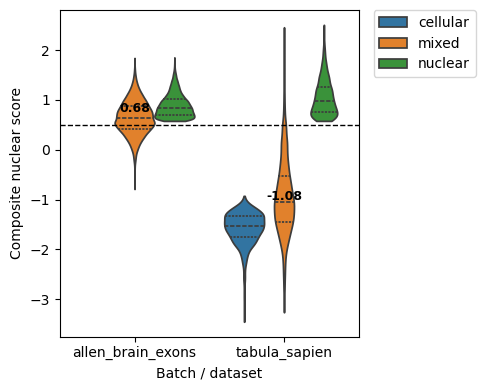

(86358, 160252)
(80780, 30340)


(None, None)

In [9]:
# Summarize with plot 
cls_col   = 'nuclear_class'
score_col = 'nuclear_ratio'   # or nuclear_score_length_norm

palette   = {'cellular':'#d62728', 'mixed':'#ff7f0e', 'nuclear':'#2ca02c'}

fig, ax = plt.subplots(figsize=(5,4))

# 1️violin per batch
sns.violinplot(
    data = ge_adata.obs,
    hue = cls_col,
    x    = 'batch',
    y    = score_col,
    ax   = ax,
    inner='quartile',      # draw the Q1–median–Q3 bars
    cut  = 0
)

# Move legend outside of plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 2️dashed line at y = 0.5
ax.axhline(0.5, ls='--', lw=1, color='black')

# 3️annotate median for each batch
medians = ge_adata.obs.groupby('batch')[score_col].median()
for tick, batch in enumerate(medians.index):
    y = medians[batch]
    ax.text(tick, y + 0.02,          # slight upward offset
            f"{y:.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Composite nuclear score')
ax.set_xlabel('Batch / dataset')
plt.tight_layout()
plt.show()
print(splice_adata.shape), print(ge_adata.shape)

In [11]:
# read the aging-gene table 
print("=== LOADING AGING GENES ===")
df = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/global_aging_genes.tsv", sep="\t")
# positive genes = those whose coefficient > 0  (up-regulated with age)
age_pos = df.loc[df.gag_score_coef > 0, "global_aging_genes"].str.upper().tolist()
# negative genes = coefficient < 0 (down-regulated with age)
age_neg = df.loc[df.gag_score_coef < 0, "global_aging_genes"].str.upper().tolist()

=== LOADING AGING GENES ===


In [13]:
ge_adata.X = ge_adata.layers["log_norm"]
# be sure var_names are also upper-case to match
ge_adata.var_names = ge_adata.var["gene_name"]

print("=== CALCULATING AGING SCORES ===")

# --- Up-regulated gene score ---
sc.tl.score_genes(
    ge_adata,
    gene_list=age_pos,
    score_name="AgingScore_pos"
)
print("✓ Calculated aging score for up-regulated genes")

# --- Down-regulated gene score ---
sc.tl.score_genes(
    ge_adata,
    gene_list=age_neg,
    score_name="AgingScore_neg"
)
print("✓ Calculated aging score for down-regulated genes")

# Final composite (higher = "older")
ge_adata.obs["AgingScore_unweighted"] = (
    ge_adata.obs["AgingScore_pos"] - ge_adata.obs["AgingScore_neg"]
)
print("✓ Calculated composite aging score")


=== CALCULATING AGING SCORES ===
       'H2-AB1', 'H2-D1', 'H2-K1', 'LYZ2', 'RNASET2B', 'SEPW1'],
      dtype='object')
✓ Calculated aging score for up-regulated genes
       'ERBB2IP', 'HIST1H4D', 'MATR3', 'ROD1', 'SEPP1', 'SEPT2', 'SHFM1',
       'SKP1A', 'SPNB2', 'SYPL', 'USMG5', 'ZFP106', 'ZFP207'],
      dtype='object')
✓ Calculated aging score for down-regulated genes
✓ Calculated composite aging score


### Now remove any lncRNAs and then subset by common genes with splice_adata and then mark HVGs

In [14]:
# Step 1: Subset splice_adata to genes present in gene_info
valid_genes = set(gene_info["clean_gene_id"])
keep_junctions = splice_adata.var["clean_gene_id"].isin(valid_genes)
splice_adata = splice_adata[:, keep_junctions].copy()

# Step 2: Merge splice_adata.var with gene_info
# This will add new columns to .var based on clean_gene_id
splice_adata.var = splice_adata.var.merge(
    gene_info, 
    on="clean_gene_id")

splice_adata.var

,junction_id,event_id,splice_motif,annotation_status,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,clean_gene_id,gene_name,mean_transcript_length,mean_intron_length,num_transcripts,transcript_biotypes
0,chr10_100003023_100006236_-,ENSG00000107554.17_atse_1,GT-AG,three_prime,ENSG00000107554.17,5,NaN,0.0,100,0,ENSG00000107554,DNMBP,4235.750000,53611.500000,4,"protein_coding, retained_intron"
1,chr10_100003023_100009837_-,ENSG00000107554.17_atse_1,GT-AG,both,ENSG00000107554.17,5,1.0,0.0,3374,1,ENSG00000107554,DNMBP,4235.750000,53611.500000,4,"protein_coding, retained_intron"
2,chr10_1001013_1005817_+,ENSG00000107937.19_atse_2,GT-AG,both,ENSG00000107937.19,3,0.0,1.0,304354,2,ENSG00000107937,GTPBP4,1720.200000,11967.600000,5,"protein_coding, protein_coding_CDS_not_defined"
3,chr10_1001013_1007017_+,ENSG00000107937.19_atse_2,GT-AG,both,ENSG00000107937.19,3,0.0,1.0,3815,3,ENSG00000107937,GTPBP4,1720.200000,11967.600000,5,"protein_coding, protein_coding_CDS_not_defined"
4,chr10_100156234_100158983_-,ENSG00000107566.14_atse_4,GT-AG,both,ENSG00000107566.14,3,1.0,0.0,1378,4,ENSG00000107566,ERLIN1,1967.333333,31810.000000,3,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145863,chrY_7326169_7356134_+,ENSG00000293442.1_atse_1,GT-AG,both,ENSG00000293442.1,6,0.0,1.0,751,160247,ENSG00000293442,PRKY,2662.000000,41707.333333,3,lncRNA
145864,chrY_7340022_7341114_+,ENSG00000293442.1_atse_1,GT-AG,three_prime,ENSG00000293442.1,6,NaN,1.0,5731,160248,ENSG00000293442,PRKY,2662.000000,41707.333333,3,lncRNA
145865,chrY_7341234_7356134_+,ENSG00000293442.1_atse_1,GT-AG,both,ENSG00000293442.1,6,0.0,1.0,17449,160249,ENSG00000293442,PRKY,2662.000000,41707.333333,3,lncRNA
145866,chrY_7371889_7372731_+,ENSG00000293442.1_atse_2,GT-AG,five_prime,ENSG00000293442.1,2,0.0,NaN,4635,160250,ENSG00000293442,PRKY,2662.000000,41707.333333,3,lncRNA


In [15]:
print("=== STEP 1: Remove lncRNAs from ge_adata ===")

# Define lncRNA biotype keywords
lncrna_keywords = ["lncRNA", "lincRNA"]

# Identify lncRNA genes
lncrna_mask = ge_adata.var["transcript_biotypes"].str.contains(
    "|".join(lncrna_keywords), case=False, na=False
)
print(f"Removing {lncrna_mask.sum():,} lncRNA genes.")
ge_adata = ge_adata[:, ~lncrna_mask].copy()

print("=== STEP 2: Subset to genes shared with splice_adata ===")

# Compute gene overlap
splice_genes = set(splice_adata.var["clean_gene_id"])
ge_genes = set(ge_adata.var["clean_gene_id"])
common_genes = splice_genes & ge_genes

print(f"Keeping {len(common_genes):,} genes shared between GE and Splicing data.")

# Subset ge_adata to shared genes
ge_adata = ge_adata[:, ge_adata.var["clean_gene_id"].isin(common_genes)].copy()

# Also subset splice_adata to shared genes 
splice_adata = splice_adata[:, splice_adata.var["clean_gene_id"].isin(common_genes)].copy()


=== STEP 1: Remove lncRNAs from ge_adata ===
Removing 2,244 lncRNA genes.
=== STEP 2: Subset to genes shared with splice_adata ===
Keeping 11,766 genes shared between GE and Splicing data.


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [17]:
# ----------------------------------------------------------------

print("=== STEP 3: HVG selection on filtered ge_adata ===")

# Run HVG selection on length-normalized layer
sc.pp.highly_variable_genes(
    ge_adata,
    layer="length_norm",
    n_top_genes=15000,
    batch_key="dataset", 
    flavor="seurat_v3", 
    inplace=True
)

print(f"✓ Selected {ge_adata.var['highly_variable'].sum():,} HVGs.")


=== STEP 3: HVG selection on filtered ge_adata ===
✓ Selected 11,766 HVGs.


In [18]:
# ----------------------------------------------------------------

print("=== STEP 4: Align cells between ge_adata and splice_adata ===")
# Realign splice_adata to match filtered ge_adata cells
splice_adata = splice_adata[ge_adata.obs_names].copy()

# Now safe to compare
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
print(f"✓ Gene expression data filtered to {ge_adata.n_vars} genes")


=== STEP 4: Align cells between ge_adata and splice_adata ===
✓ Gene expression data filtered to 11766 genes


In [20]:
# ----------------------------------------------------------------

print("=== STEP 5: Summarize number of junction reads per cell ===")

print("=== CALCULATING JUNCTION QC METRICS ===")

# Confirm required column exists
assert "annotation_status" in splice_adata.var.columns, "Missing 'annotation_status' column in splice_adata.var"
assert "both" in splice_adata.var["annotation_status"].unique(), "'both' not found in annotation_status"

# Define annotation mask
is_annotated = splice_adata.var["annotation_status"] == "both"
is_unannotated = ~is_annotated

# Read count matrix
X_counts = splice_adata.layers["cell_by_junction_matrix"]

# Total read counts
splice_adata.obs["total_junction_reads"] = np.asarray(X_counts.sum(axis=1)).flatten()
splice_adata.obs["annotated_junction_reads"] = np.asarray(X_counts[:, is_annotated].sum(axis=1)).flatten()
splice_adata.obs["unannotated_junction_reads"] = np.asarray(X_counts[:, is_unannotated].sum(axis=1)).flatten()

# Detected junctions (binary matrix)
X_detected = X_counts > 0
splice_adata.obs["n_detected_annotated_junctions"] = np.asarray(X_detected[:, is_annotated].sum(axis=1)).flatten()
splice_adata.obs["n_detected_unannotated_junctions"] = np.asarray(X_detected[:, is_unannotated].sum(axis=1)).flatten()

# Apply filters based on 1st and 99th percentiles
def quantile_filter(series, lower=0.01, upper=0.99):
    q_low, q_high = series.quantile([lower, upper])
    return (series >= q_low) & (series <= q_high)

read_filter = quantile_filter(splice_adata.obs["total_junction_reads"])
junctions_filter = quantile_filter(splice_adata.obs["n_detected_annotated_junctions"])

# Additional filter: cell must have at least 100 total junction reads
min_reads_filter = splice_adata.obs["total_junction_reads"] > 1000
min_junctions_filter = splice_adata.obs["n_detected_annotated_junctions"] >= 2

# Final per-cell QC: within percentile range AND above minimum count
splice_qc_filter = read_filter & junctions_filter & min_reads_filter & min_junctions_filter

# Filter both datasets
cells_before_filter = splice_adata.shape[0]
ge_adata = ge_adata[splice_qc_filter].copy()
splice_adata = splice_adata[splice_qc_filter].copy()
cells_after_filter = splice_adata.shape[0]  
print(f"Cells lost due to junction-based per-cell QC filters: {cells_before_filter - cells_after_filter}")

print("✓ Applied junction-based per-cell QC filters")

# ----------------------------------------------------------------

print("=== APPLYING JUNCTION-LEVEL QC FILTERS ===")

# Recompute total read counts per junction
junction_counts = np.asarray(splice_adata.layers["cell_by_junction_matrix"].sum(axis=0)).flatten()
junction_detected = np.asarray((splice_adata.layers["cell_by_junction_matrix"] > 0).sum(axis=0)).flatten()

# Annotate junctions based on detection across cells
detected_in_cells = np.asarray((X_counts > 0).sum(axis=0)).flatten()
splice_adata.var["n_cells_detected"] = detected_in_cells
splice_adata.var["confidence"] = np.where(
    splice_adata.var["n_cells_detected"] <= 100, "low", "high"
)
print(f"✓ Annotated {np.sum(splice_adata.var['confidence'] == 'low')} junctions as 'low confidence'")


=== STEP 5: Summarize number of junction reads per cell ===
=== CALCULATING JUNCTION QC METRICS ===
Cells lost due to junction-based per-cell QC filters: 2753
✓ Applied junction-based per-cell QC filters
=== APPLYING JUNCTION-LEVEL QC FILTERS ===
✓ Annotated 60591 junctions as 'low confidence'


In [21]:
# ----------------------------------------------------------------
print("=== RE-SUBSETTING AND VALIDATING FINAL ALIGNMENT ===")

# Step 1: Realign cells — ensure identical cell set in both
common_cells = ge_adata.obs_names.intersection(splice_adata.obs_names)
print(f"Re-aligning to {len(common_cells)} common cells")
ge_adata = ge_adata[common_cells].copy()
splice_adata = splice_adata[common_cells].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

# Step 2: Filter again for cell types with ≥50 cells
cell_type_counts = ge_adata.obs['broad_cell_type'].value_counts()
valid_cell_types = cell_type_counts[cell_type_counts >= 50].index
print(f"Cell types retained after final filtering: {len(valid_cell_types)}")

cell_mask = ge_adata.obs['broad_cell_type'].isin(valid_cell_types)
ge_adata = ge_adata[cell_mask].copy()
splice_adata = splice_adata[cell_mask].copy()
print(f"✓ Retained {ge_adata.n_obs} cells after final broad cell type filtering")

# Step 3: Recheck shared genes
shared_genes = set(ge_adata.var["gene_name"]).intersection(set(splice_adata.var["gene_name"]))
print(f"✓ {len(shared_genes)} genes shared between gene expression and splicing data")

ge_adata = ge_adata[:, ge_adata.var["gene_name"].isin(shared_genes)].copy()
splice_adata = splice_adata[:, splice_adata.var["gene_name"].isin(shared_genes)].copy()

# Final sanity checks
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
print("✓ Final alignment confirmed between gene expression and splicing datasets")

=== RE-SUBSETTING AND VALIDATING FINAL ALIGNMENT ===
Re-aligning to 75396 common cells
Cell types retained after final filtering: 42
✓ Retained 75323 cells after final broad cell type filtering
✓ 11766 genes shared between gene expression and splicing data
✓ Final alignment confirmed between gene expression and splicing datasets


In [22]:
print("=== FINAL DATA SUMMARY ===")
print(f"Final number of unique cells in splice_adata: {splice_adata.n_obs}")
print(f"Final number of unique junctions in splice_adata: {splice_adata.n_vars}")
print(f"Final number of unique ATSEs in splice_adata: {splice_adata.var['event_id'].nunique()}")
print(f"Final number of unique genes in splice_adata: {splice_adata.var['gene_name'].nunique()}")

print(f"Final number of unique cells in ge_adata: {ge_adata.n_obs}")
print(f"Final number of unique genes in ge_adata: {ge_adata.n_vars}")

=== FINAL DATA SUMMARY ===
Final number of unique cells in splice_adata: 75323
Final number of unique junctions in splice_adata: 141843
Final number of unique ATSEs in splice_adata: 37403
Final number of unique genes in splice_adata: 11766
Final number of unique cells in ge_adata: 75323
Final number of unique genes in ge_adata: 11766


In [23]:
print("=== ADDING COMPUTED SCORES TO SPLICE DATA ===")
# add the new .obs columns to the splice_adata
splice_adata.obs["broad_cell_type"] = ge_adata.obs["broad_cell_type"]
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["AgingScore_pos"] = ge_adata.obs["AgingScore_pos"]
splice_adata.obs["AgingScore_neg"] = ge_adata.obs["AgingScore_neg"]
print("✓ Added aging scores and cell type annotations to splice data")

print("=== ADDING COMPUTED NUCLEAR RATIO SCORES TO SPLICE DATA ===")
splice_adata.obs["nuclear_ratio"] = ge_adata.obs["nuclear_ratio"]
splice_adata.obs["nuclear_class"] = ge_adata.obs["nuclear_class"]
splice_adata.obs["nuclear_score"] = ge_adata.obs["nuclear_score"]
splice_adata.obs["nuclear_rrna"] = ge_adata.obs["nuclear_rrna"]

=== ADDING COMPUTED SCORES TO SPLICE DATA ===
✓ Added aging scores and cell type annotations to splice data
=== ADDING COMPUTED NUCLEAR RATIO SCORES TO SPLICE DATA ===


In [24]:
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [29]:
splice_adata.obs["total_junction_reads"].min()

1028

In [30]:
import os
from datetime import datetime

# Set new model date and shared output directory
new_model_date = "072025"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
GE_OUTPUT_DIR = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/{new_model_date}"
os.makedirs(GE_OUTPUT_DIR, exist_ok=True)

# ---- Gene Expression ----
ge_new_filename = f"aligned_gene_expression_data_{timestamp}.h5ad"
GE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, ge_new_filename)

# Save filtered gene expression data
ge_adata.write(GE_OUTPUT_PATH, compression="lzf")
print(f"Filtered gene expression AnnData written to:\n{GE_OUTPUT_PATH}")

# ---- Splicing Data ----
splice_new_filename = f"aligned_splicing_data_{timestamp}.h5ad"
SPLICE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, splice_new_filename)
# Subset and save matched splicing data
splice_adata.write(SPLICE_OUTPUT_PATH, compression="lzf")
print(f"Filtered splicing AnnData written to:\n{SPLICE_OUTPUT_PATH}")

Filtered gene expression AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/072025/aligned_gene_expression_data_20250731_212313.h5ad
Filtered splicing AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/072025/aligned_splicing_data_20250731_212313.h5ad


In [31]:
# Save also text file with just final list of cell ids 
with open(os.path.join(GE_OUTPUT_DIR, f"filtered_cell_ids.txt_{timestamp}"), "w") as f:
    for cell_id in ge_adata.obs_names:
        f.write(f"{cell_id}\n")